## **Классификация мест залежей нефти и газа**

### Шаг 1. Анализ данных

In [1]:
#Импортируем библиотеки
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

In [2]:
# Считываем и анализируем датасет
df = pd.read_csv('train_oil.csv')
df.head()

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


In [3]:
# Шаг 1. Проанализируем данные
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [4]:
df.describe()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
count,282.00000,279.000000,309.000000,309.000000,309.000000,309.000000,309.000000
mean,35.62426,-12.508435,6755.669903,760.087379,183.683236,17.825178,476.994757
std,22.19116,86.387220,3628.094135,1353.934404,282.252489,7.171048,1000.140605
min,-38.39890,-151.615300,220.000000,11.000000,2.120000,1.100000,0.010000
25%,28.24915,-102.336500,4059.000000,128.000000,45.000000,12.000000,10.000000
50%,38.13500,1.810000,6500.000000,312.000000,110.000000,17.000000,68.000000
75%,52.13360,56.179900,9186.000000,715.000000,205.000000,23.600000,390.000000
max,76.44620,148.417000,19888.000000,8200.000000,2976.000000,35.000000,7500.000000


In [5]:
df_nan = df.loc[:, df.isnull().any()]
# посмотрим процент пропущенных значений
df_nan.isnull().sum() / len(df_nan) * 100

Country        8.737864
Region        12.297735
Basin name    12.297735
Latitude       8.737864
Longitude      9.708738
dtype: float64

In [6]:
# Количество уникальных значений
df.nunique().sort_values()

Onshore/Offshore                    3
Hydrocarbon type                    4
Region                              7
Reservoir status                   13
Lithology                          13
Reservoir period                   22
Country                            42
Structural setting                 43
Tectonic regime                    55
Porosity                           68
Basin name                         93
Operator company                  138
Permeability                      151
Thickness (net pay average ft)    166
Thickness (gross average ft)      166
Reservoir unit                    258
Longitude                         260
Latitude                          262
Depth                             279
Field name                        285
dtype: int64

C:\Users\admin\AppData\Local\Temp\ipykernel_33544\2808798622.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x ='Onshore/Offshore', data = df, palette='hls')


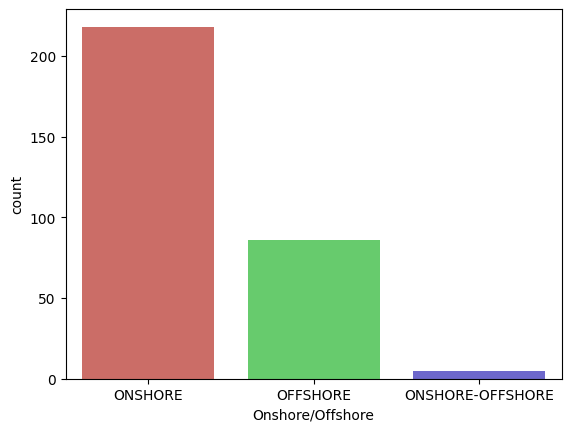

In [7]:
# Проверка дисбаланса классов

sns.countplot(x ='Onshore/Offshore', data = df, palette='hls')
plt.show()

Вывод по анализу: в тренеровочном датасете есть пропуски в 5 признаках: Country, Region, Basin name, Latitude, Longitude. Присутствуют как числовые, так и категориальные признаки. Анализ распределения числовых признаков показал наличие выбросов в некоторых параметрах (например, Permeability, Depth и Thickness). На данный момент нельзя однозначно сказать, действительные ли это значения или ошибки в даных, в связи с этим удаление выбросов не выполнялось.Также ярко выражен дисбаланс классов. Это может привести к тому, что модель будет предсказывать преимущественно класс, представленный в большем количестве.

### Шаг 2. Предобработка данных.
#### Шаг 2.1 Обработка числовых признаков

In [8]:
df_copy = df.copy()

# Удаляем столбец с идентификатором
df_copy = df_copy.drop('Field name', axis=1)

# Заполнение пропусков
# Обработка числовых признаков - заполняем медианой
num_cols = df_copy.select_dtypes(include=['int64', 'float64']).columns
df_copy[num_cols] = df_copy[num_cols].fillna(df_copy[num_cols].median())

# Введем новый признак Thickness_ratio = Thickness (net pay average ft) /Thickness (gross average ft)
df_copy['Thickness_ratio'] = (
    df_copy['Thickness (net pay average ft)'] /
    (df_copy['Thickness (gross average ft)'] + 1e-6)
)

#### Шаг 2.2 Обработка категориальных признаков

Рассмотрим, какие признаки можно удалить. 
Reservoir unit - слишком много уникальных значений - лучше удалить.
Operator company - не имеет прямого отношения к геологии - лучше удалить. Остальные категориальные признаки могут нести важную информацию.

In [9]:
# Удаление признаков
df_copy = df_copy.drop('Reservoir unit', axis=1)
df_copy = df_copy.drop('Operator company', axis=1)

In [10]:
# Обработка пропусков категориальных признаков
cat_cols = df_copy.select_dtypes(include='object').columns
cat_cols = cat_cols.drop('Onshore/Offshore')
df_copy[cat_cols] = df_copy[cat_cols].fillna('Unknown')

# Разделяем признаки и target
X = df_copy.drop('Onshore/Offshore', axis=1)
y = df_copy['Onshore/Offshore']

# Перед кодировкой делим на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# Проверка пропусков
df_copy.isnull().sum()

Country                           0
Region                            0
Basin name                        0
Tectonic regime                   0
Latitude                          0
Longitude                         0
Onshore/Offshore                  0
Hydrocarbon type                  0
Reservoir status                  0
Structural setting                0
Depth                             0
Reservoir period                  0
Lithology                         0
Thickness (gross average ft)      0
Thickness (net pay average ft)    0
Porosity                          0
Permeability                      0
Thickness_ratio                   0
dtype: int64

In [12]:
# Применяем One Hot encoder
one_hot_encoder = preprocessing.OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)
one_hot_encoder.fit(X_train[cat_cols])
X_train_encoded = one_hot_encoder.transform(X_train[cat_cols])
X_valid_encoded = one_hot_encoder.transform(X_valid[cat_cols])

#Получаем новые признаки
encoded_columns = one_hot_encoder.get_feature_names_out(cat_cols)

# Преобразуем в DataFrame
X_train_encoded_df = pd.DataFrame(
    X_train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

X_valid_encoded_df = pd.DataFrame(
    X_valid_encoded,
    columns=encoded_columns,
    index=X_valid.index
)

# Удаляем исходные категориальные признаки
X_train = X_train.drop(columns=cat_cols)
X_valid = X_valid.drop(columns=cat_cols)

# Собираем обратно
X_train = pd.concat([X_train, X_train_encoded_df], axis=1)
X_valid = pd.concat([X_valid, X_valid_encoded_df], axis=1)

In [13]:
# Проверка размеров
print(X_train.shape, X_valid.shape)

(247, 272) (62, 272)


In [14]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Кодирование целевой переменной
target_encoder = LabelEncoder()
y_train = target_encoder.fit_transform(y_train)
y_valid = target_encoder.transform(y_valid)

# Масштабирование числовых признаков
num_cols_final = X_train.select_dtypes(include=['int64', 'float64']).columns

scaler = StandardScaler()
X_train[num_cols_final] = scaler.fit_transform(X_train[num_cols_final])
X_valid[num_cols_final] = scaler.transform(X_valid[num_cols_final])

print(X_train.shape, X_valid.shape)
print(np.unique(y_train), np.unique(y_valid))

(247, 272) (62, 272)
[0 1 2] [0 1 2]


Вывод: Выполнена предобработка данных. Из исходного датасета были удалёны признаки Field name, Reservoir unit, Operator Company. Пропущенные значения в числовых признаках были заполнены медианными значениями. Дополнительно был сформирован новый информативный признак Thickness_ratio, отражающий отношение эффективной толщины продуктивного пласта к общей толщине.

Категориальные признаки были обработаны отдельно: пропущенные значения заменены на значение Unknown, после чего выполнено кодирование методом One-Hot Encoding с использованием класса OneHotEncoder библиотеки sklearn. Выполнено масштабирование числовых признаков.

### Шаг 3. Обучение модели

In [15]:
# Перед тем, как обучить модель, сбалансируем классы
print(pd.Series(y_train).value_counts())

1    174
0     69
2      4
Name: count, dtype: int64


In [16]:
# Балансировка методом SMOTE
from imblearn.over_sampling import SMOTE

print('Распределение классов ДО SMOTE:')
print(pd.Series(y_train).value_counts())

# Применяем k_neighbors=2, т.к.класс 2 содержит всего 4 значения
smote = SMOTE(random_state=42, k_neighbors=2)

columns = X_train.columns
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote = pd.DataFrame(X_train_smote, columns=columns)
y_train_smote = pd.Series(y_train_smote)

print(f'Размер обучающей выборки после SMOTE: {X_train_smote.shape}')
print('Распределение классов ПОСЛЕ SMOTE:')
print(y_train_smote.value_counts())

Распределение классов ДО SMOTE:
1    174
0     69
2      4
Name: count, dtype: int64
Размер обучающей выборки после SMOTE: (522, 272)
Распределение классов ПОСЛЕ SMOTE:
1    174
0    174
2    174
Name: count, dtype: int64


#### KNN

In [17]:
# Обучение модели KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

knn = KNeighborsClassifier(15)

# обучаем модель на сбалансированной выборке
knn.fit(X_train_smote, y_train_smote)

# предсказываем значения на валидационной выборке
y_pred = knn.predict(X_valid)

Расчет метрик

In [18]:
accuracy = accuracy_score(y_valid, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7742


In [19]:
precision_macro = precision_score(y_valid, y_pred, average='macro')
precision_micro = precision_score(y_valid, y_pred, average='micro')
precision_weighted = precision_score(y_valid, y_pred, average='weighted')

print(f"Precision Macro: {precision_macro:.4f}")
print(f"Precision Micro: {precision_micro:.4f}")
print(f"Precision Weighted: {precision_weighted:.4f}")

Precision Macro: 0.4976
Precision Micro: 0.7742
Precision Weighted: 0.7691


In [20]:
recall_macro = recall_score(y_valid, y_pred, average='macro')
recall_micro = recall_score(y_valid, y_pred, average='micro')
recall_weighted = recall_score(y_valid, y_pred, average='weighted')

print(f"Recall Macro: {recall_macro:.4f}")
print(f"Recall Micro: {recall_micro:.4f}")
print(f"Recall Weighted: {recall_weighted:.4f}")

Recall Macro: 0.4840
Recall Micro: 0.7742
Recall Weighted: 0.7742


In [21]:
f1_macro = f1_score(y_valid, y_pred, average='macro')
f1_micro = f1_score(y_valid, y_pred, average='micro')
f1_weighted = f1_score(y_valid, y_pred, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

F1 Macro: 0.4898
F1 Micro: 0.7742
F1 Weighted: 0.7707


In [22]:
print(classification_report(y_valid, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.59      0.62        17
           1       0.83      0.86      0.84        44
           2       0.00      0.00      0.00         1

    accuracy                           0.77        62
   macro avg       0.50      0.48      0.49        62
weighted avg       0.77      0.77      0.77        62



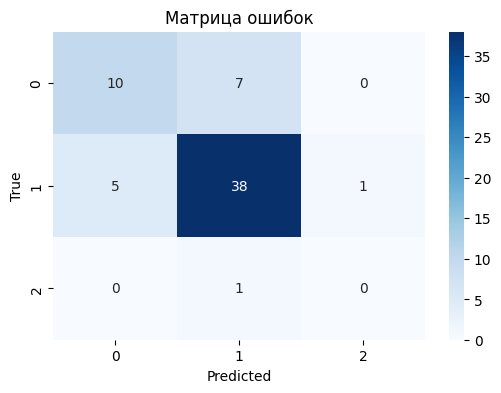

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

#### LogisticRegression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

y_pred_log = log_reg.predict(X_valid)

print(f"Accuracy: {accuracy_score(y_valid, y_pred_log):.4f}")
print(f"Precision Macro: {precision_score(y_valid, y_pred_log, average='macro'):.4f}")
print(f"Recall Macro: {recall_score(y_valid, y_pred_log, average='macro'):.4f}")
print(f"F1 Macro: {f1_score(y_valid, y_pred_log, average='macro'):.4f}")

Accuracy: 0.8871
Precision Macro: 0.5954
Recall Macro: 0.5851
F1 Macro: 0.5899


#### RandomForest

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_valid)

print(f"Accuracy: {accuracy_score(y_valid, y_pred_rf):.4f}")
print(f"Precision Macro: {precision_score(y_valid, y_pred_rf, average='macro'):.4f}")
print(f"Recall Macro: {recall_score(y_valid, y_pred_rf, average='macro'):.4f}")
print(f"F1 Macro: {f1_score(y_valid, y_pred_rf, average='macro'):.4f}")

Accuracy: 0.8548
Precision Macro: 0.5574
Recall Macro: 0.5459
F1 Macro: 0.5504


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


#### Сравнение моделей

In [26]:
results = pd.DataFrame({
    'Model': ['KNN', 'LogisticRegression', 'RandomForest'],
    'Accuracy': [
        accuracy_score(y_valid, y_pred),
        accuracy_score(y_valid, y_pred_log),
        accuracy_score(y_valid, y_pred_rf)
    ],
    'F1_macro': [
        f1_score(y_valid, y_pred, average='macro'),
        f1_score(y_valid, y_pred_log, average='macro'),
        f1_score(y_valid, y_pred_rf, average='macro')
    ]
})

results.sort_values('F1_macro', ascending=False)

,Model,Accuracy,F1_macro
1,LogisticRegression,0.887097,0.589944
2,RandomForest,0.854839,0.550366
0,KNN,0.774194,0.489815


Вывод: Были обучены три модели: KNN, LogisticRegression и RandomForest на сбалансированной выборке после применения SMOTE. По результатам сравнения лучшей считается модель, показавшая наибольшее значение F1_macro - LogisticRegression. Вероятно это связано с относительно небольшим количеством объектов и множеством OneHotEncoder признаков.

### Шаг 4. Оценка важности признаков

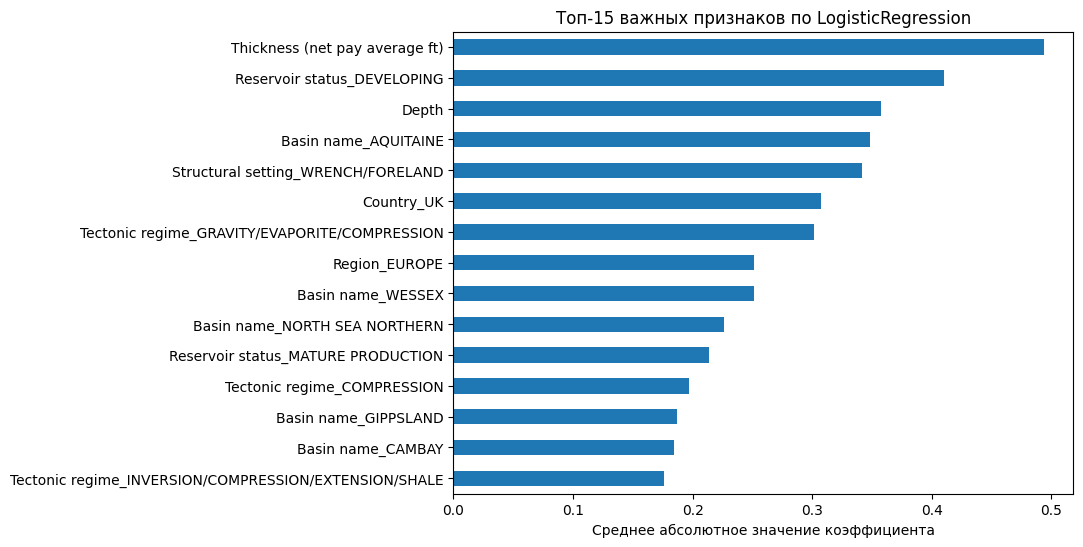

Thickness (net pay average ft)                           0.493656
Reservoir status_DEVELOPING                              0.410459
Depth                                                    0.357705
Basin name_AQUITAINE                                     0.348224
Structural setting_WRENCH/FORELAND                       0.341695
Country_UK                                               0.307426
Tectonic regime_GRAVITY/EVAPORITE/COMPRESSION            0.301679
Region_EUROPE                                            0.251681
Basin name_WESSEX                                        0.251021
Basin name_NORTH SEA NORTHERN                            0.226223
Reservoir status_MATURE PRODUCTION                       0.214097
Tectonic regime_COMPRESSION                              0.197138
Basin name_GIPPSLAND                                     0.187368
Basin name_CAMBAY                                        0.184888
Tectonic regime_INVERSION/COMPRESSION/EXTENSION/SHALE    0.175905
dtype: flo

In [27]:
# Визуализируем коэффициенты влияния признаков
coef_importance = pd.Series(
    np.mean(np.abs(log_reg.coef_), axis=0),
    index=X_train_smote.columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
coef_importance.head(15).sort_values().plot(kind='barh')
plt.title('Топ-15 важных признаков по LogisticRegression')
plt.xlabel('Среднее абсолютное значение коэффициента')
plt.show()

coef_importance.head(15)

### Шаг 5. Подбор гиперпараметров

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'newton-cg', 'saga']
}

grid_log = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

grid_log.fit(X_train_smote, y_train_smote)

print('Лучшие параметры:', grid_log.best_params_)
print(f'Лучший CV score: {grid_log.best_score_:.3f}')

Лучшие параметры: {'C': 100, 'solver': 'newton-cg'}
Лучший CV score: 0.961


In [29]:
best_log_reg = grid_log.best_estimator_

y_pred_best_log = best_log_reg.predict(X_valid)

print(f"Accuracy: {accuracy_score(y_valid, y_pred_best_log):.4f}")
print(f"Precision Macro: {precision_score(y_valid, y_pred_best_log, average='macro'):.4f}")
print(f"Recall Macro: {recall_score(y_valid, y_pred_best_log, average='macro'):.4f}")
print(f"F1 Macro: {f1_score(y_valid, y_pred_best_log, average='macro'):.4f}")

Accuracy: 0.8710
Precision Macro: 0.5860
Recall Macro: 0.5655
F1 Macro: 0.5745


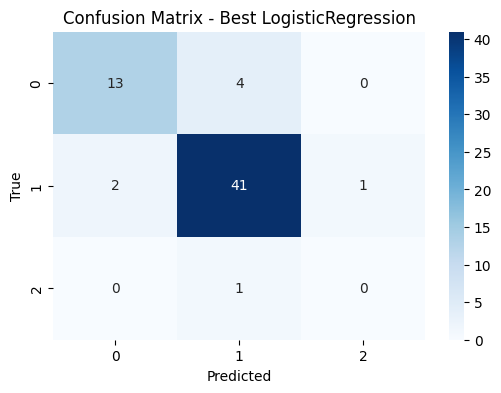

In [30]:
# Матрица ошибок после подбора гиперпараметров
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_valid, y_pred_best_log)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Best LogisticRegression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Вывод: Для подбора гиперпараметров использовалась кросс-валидация с числом разбиений cv=5.  Такой выбор обусловлен небольшим размером датасета и позволяет получить более устойчивую оценку качества модели. В ходе подбора гиперпараметров методом GridSearchCV были получены оптимальные значения параметров модели LogisticRegression: C = 100 и solver = newton-cg.

### Шаг 6. Делаем предсказание для тестовой выборки

In [31]:
# Загружаем тестовые данные
test_df = pd.read_csv('oil_test.csv')
test_copy = test_df.copy()

# Аналогичным способом обрабатываем признаки
test_copy = test_copy.drop(['Field name', 'Reservoir unit', 'Operator company'], axis=1)

test_copy['Thickness_ratio'] = (
    test_copy['Thickness (net pay average ft)'] /
    (test_copy['Thickness (gross average ft)'] + 1e-6)
)
test_num_cols = test_copy.select_dtypes(include=['int64', 'float64']).columns
test_cat_cols = test_copy.select_dtypes(include='object').columns

train_medians = df_copy.drop(columns=['Onshore/Offshore']).select_dtypes(include=['int64', 'float64']).median()
test_copy[test_num_cols] = test_copy[test_num_cols].fillna(train_medians)

test_copy[test_cat_cols] = test_copy[test_cat_cols].fillna('Unknown')

# Кодируем категориальные признаки тем же encoder
test_encoded = one_hot_encoder.transform(test_copy[test_cat_cols])

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=one_hot_encoder.get_feature_names_out(test_cat_cols),
    index=test_copy.index
)

# Удаляем исходные категориальные признаки
test_copy = test_copy.drop(columns=test_cat_cols)

# Собираем итоговый test
test_processed = pd.concat([test_copy, test_encoded_df], axis=1)
test_processed = test_processed.reindex(columns=X_train.columns, fill_value=0)

# Масштабируем признаки
test_processed[num_cols_final] = scaler.transform(test_processed[num_cols_final])

test_processed.head()

,Latitude,Longitude,Depth,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability,Thickness_ratio,Country_AFGHANISTAN,Country_ANGOLA,...,Lithology_DOLOMITE,Lithology_DOLOMITIC LIMESTONE,Lithology_LIMESTONE,Lithology_LOW-RESISTIVITY SANDSTONE,Lithology_SANDSTONE,Lithology_SHALE,Lithology_SHALY SANDSTONE,Lithology_SILTSTONE,Lithology_THINLY-BEDDED SANDSTONE,Lithology_VOLCANICS
0,-0.266166,0.492283,1.005693,0.008658,-0.087787,-1.104109,-0.464134,-0.779851,-0.063758,-0.063758,...,-0.413057,-0.110883,-0.357567,-0.14374,0.804156,-0.063758,-0.14374,-0.090351,-0.1283,-0.063758
1,-0.187418,0.527057,1.065888,-0.166188,0.998088,0.293655,-0.182449,1.524464,-0.063758,-0.063758,...,-0.413057,-0.110883,-0.357567,-0.14374,0.804156,-0.063758,-0.14374,-0.090351,-0.1283,-0.063758
2,0.603578,0.845882,-0.182115,-0.321031,-0.246994,-1.104109,-0.452558,-0.190002,-0.063758,-0.063758,...,-0.413057,-0.110883,2.796682,-0.14374,-1.243540,-0.063758,-0.14374,-0.090351,-0.1283,-0.063758
3,1.175117,0.167954,0.869214,0.113121,0.728660,-0.125674,0.010486,-0.045988,-0.063758,-0.063758,...,-0.413057,-0.110883,-0.357567,-0.14374,0.804156,-0.063758,-0.14374,-0.090351,-0.1283,-0.063758
4,-0.644220,1.030716,-1.028172,-0.046907,-0.675628,0.433431,-0.230683,-1.507372,-0.063758,-0.063758,...,-0.413057,-0.110883,-0.357567,-0.14374,0.804156,-0.063758,-0.14374,-0.090351,-0.1283,-0.063758


In [32]:
predictions = best_log_reg.predict(test_processed)

submission = pd.DataFrame({
    'index': test_df.index,
    'Onshore/Offshore': predictions
})

submission.to_csv('submission.csv', index=False)

submission.head()

,index,Onshore/Offshore
0,0,1
1,1,1
2,2,1
3,3,0
4,4,1


Скриншот с Kaggle

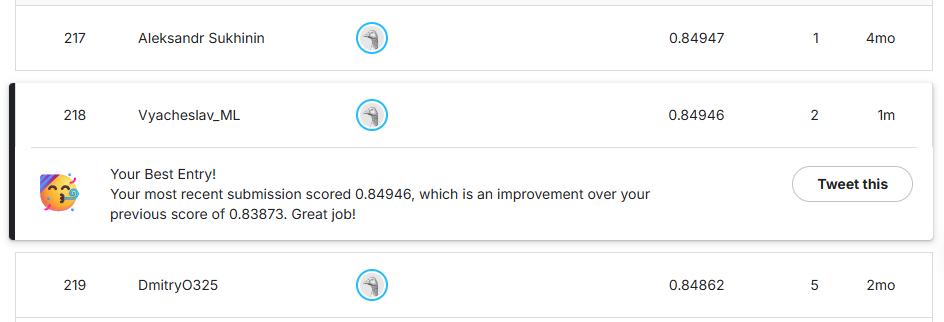

Выводы по работе: в ходе практической работы был проанализирован и предобработан датасет месторождений нефти и газа с целью построения модели, классифицирующей месторождения Offshore/Onshore. Для устранения дисбаланса классов применён метод SMOTE. Были обучены и сравнены модели KNN, LogisticRegression и RandomForest. Выбрана модель LogisticRegression по метрике оценки f1-score (т.к. классы несбалансированы). Выполнен подбор гиперпараметров методом GridSearchCV и сделаны предсказания на тестовой выборке.